In [12]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [13]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [14]:
ts = pd.read_csv('MOD-00692.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:12Z,21.729,1.378,0.226,0.085,0.028,0.034,24.123,774.794,22.724,2.896,34.593,49.9,0.2
1,2025-12-31T18:58:12Z,9.733,0.906,0.247,0.116,0.062,0.013,7.564,739.435,23.490,2.559,34.140,49.4,0.2
2,2025-12-31T18:57:12Z,7.114,0.735,0.261,0.044,0.039,0.032,8.837,732.687,23.823,2.768,33.655,49.5,0.1
3,2025-12-31T18:56:12Z,7.072,0.655,0.242,0.094,0.068,0.011,7.876,739.114,23.447,2.896,33.883,49.7,0.1
4,2025-12-31T18:55:12Z,7.851,0.916,0.297,0.113,0.051,0.016,8.310,747.379,23.385,2.907,34.810,50.2,0.1


In [15]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:12,21.729,1.378,0.226,0.085,0.028,0.034,24.123,774.794,22.724,2.896,34.593,49.9,0.2
1,2025-12-31 18:58:12,9.733,0.906,0.247,0.116,0.062,0.013,7.564,739.435,23.490,2.559,34.140,49.4,0.2
2,2025-12-31 18:57:12,7.114,0.735,0.261,0.044,0.039,0.032,8.837,732.687,23.823,2.768,33.655,49.5,0.1
3,2025-12-31 18:56:12,7.072,0.655,0.242,0.094,0.068,0.011,7.876,739.114,23.447,2.896,33.883,49.7,0.1
4,2025-12-31 18:55:12,7.851,0.916,0.297,0.113,0.051,0.016,8.310,747.379,23.385,2.907,34.810,50.2,0.1


## Full Timeseries Plot

In [16]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-05-27,4.029064,0.519166,0.204057,0.057224,0.052667,0.033090,4.401980,886.096507,43.538565,2.588616,29.939676,41.360644,22.860465
2025-05-28,5.807968,0.685066,0.224237,0.067165,0.068063,0.045125,5.215910,798.869594,36.564753,2.395031,30.591464,58.904444,17.459722
2025-05-29,11.962504,1.231019,0.331366,0.089677,0.091949,0.064376,6.164275,822.865161,31.908083,2.360722,24.313024,78.251528,17.975208
2025-05-30,19.094965,4.447833,1.378856,0.307365,0.185583,0.056333,8.548170,845.053470,30.248644,1.895931,26.772196,72.458333,21.104792
2025-05-31,8.187988,2.152769,0.808717,0.192894,0.125590,0.039731,3.523942,675.909808,38.481865,2.199053,13.949612,66.916181,17.925833


In [17]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-05-27,4.029064,0.519166,0.204057,0.057224,0.052667,0.033090,4.401980,886.096507,43.538565,2.588616,29.939676,41.360644,22.860465,5.682823
2025-05-28,5.807968,0.685066,0.224237,0.067165,0.068063,0.045125,5.215910,798.869594,36.564753,2.395031,30.591464,58.904444,17.459722,4.949036
2025-05-29,11.962504,1.231019,0.331366,0.089677,0.091949,0.064376,6.164275,822.865161,31.908083,2.360722,24.313024,78.251528,17.975208,4.622065
2025-05-30,19.094965,4.447833,1.378856,0.307365,0.185583,0.056333,8.548170,845.053470,30.248644,1.895931,26.772196,72.458333,21.104792,6.486540
2025-05-31,8.187988,2.152769,0.808717,0.192894,0.125590,0.039731,3.523942,675.909808,38.481865,2.199053,13.949612,66.916181,17.925833,3.630538


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-514874767.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


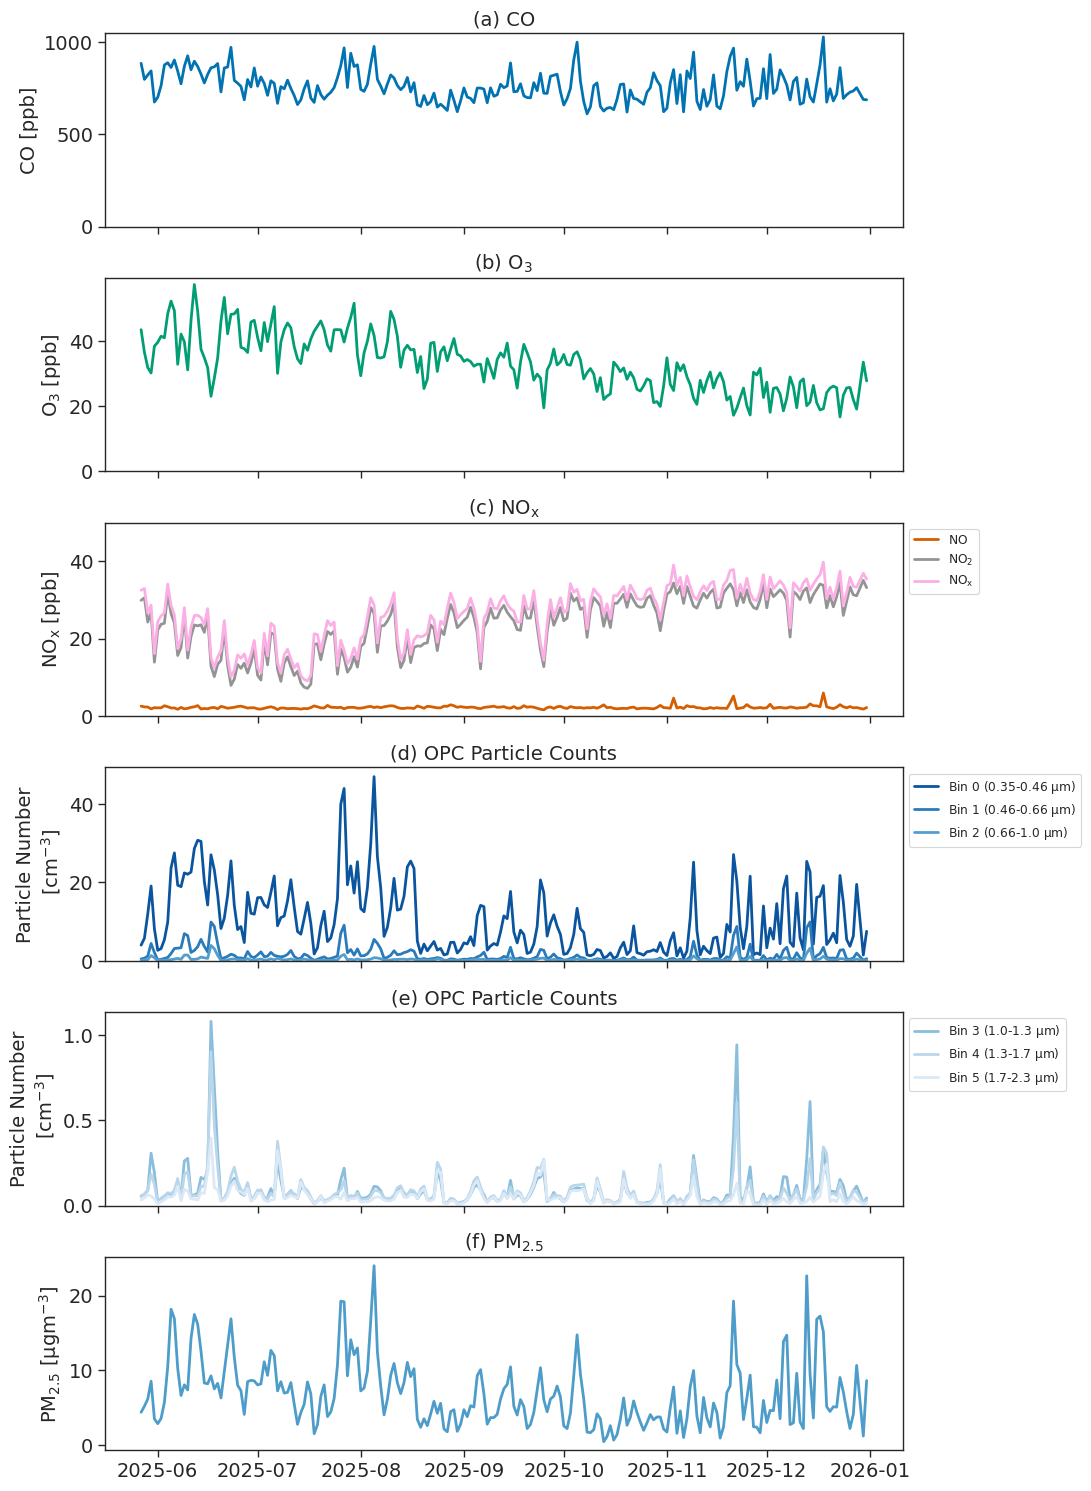

In [18]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/timeseries_MOD-00068.png')

## Dirunal Plots

In [19]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-05-27 14:00:00,4.404895,0.426842,0.150421,0.035500,0.041667,0.029167,7.058889,725.920722,51.733167,2.268667,13.966611,28.757895,27.647368
2025-05-27 15:00:00,4.069783,0.454250,0.154917,0.038300,0.037350,0.022467,6.151050,773.013583,52.292650,2.301850,23.047433,30.191667,26.738333
2025-05-27 16:00:00,3.978233,0.452267,0.173800,0.048567,0.049583,0.030067,4.484667,872.122700,50.222717,2.455000,30.014967,35.103333,25.531667
2025-05-27 17:00:00,3.785383,0.444283,0.184617,0.054967,0.055600,0.040000,3.715817,931.487917,48.272367,2.512733,31.235817,38.311667,23.711667
2025-05-27 18:00:00,3.911833,0.535150,0.215033,0.064917,0.061800,0.038883,3.371817,904.891483,44.823300,2.349117,31.505433,39.431667,22.640000


In [20]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-05-27 14:00:00,4.404895,0.426842,0.150421,0.035500,0.041667,0.029167,7.058889,725.920722,51.733167,2.268667,13.966611,28.757895,27.647368,6.287107
2025-05-27 15:00:00,4.069783,0.454250,0.154917,0.038300,0.037350,0.022467,6.151050,773.013583,52.292650,2.301850,23.047433,30.191667,26.738333,6.005530
2025-05-27 16:00:00,3.978233,0.452267,0.173800,0.048567,0.049583,0.030067,4.484667,872.122700,50.222717,2.455000,30.014967,35.103333,25.531667,5.566494
2025-05-27 17:00:00,3.785383,0.444283,0.184617,0.054967,0.055600,0.040000,3.715817,931.487917,48.272367,2.512733,31.235817,38.311667,23.711667,5.323377
2025-05-27 18:00:00,3.911833,0.535150,0.215033,0.064917,0.061800,0.038883,3.371817,904.891483,44.823300,2.349117,31.505433,39.431667,22.640000,5.194161


In [21]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-05-27 14:00:00,4.404895,0.426842,0.150421,0.035500,0.041667,0.029167,7.058889,725.920722,51.733167,2.268667,13.966611,28.757895,27.647368,6.287107,14
2025-05-27 15:00:00,4.069783,0.454250,0.154917,0.038300,0.037350,0.022467,6.151050,773.013583,52.292650,2.301850,23.047433,30.191667,26.738333,6.005530,15
2025-05-27 16:00:00,3.978233,0.452267,0.173800,0.048567,0.049583,0.030067,4.484667,872.122700,50.222717,2.455000,30.014967,35.103333,25.531667,5.566494,16
2025-05-27 17:00:00,3.785383,0.444283,0.184617,0.054967,0.055600,0.040000,3.715817,931.487917,48.272367,2.512733,31.235817,38.311667,23.711667,5.323377,17
2025-05-27 18:00:00,3.911833,0.535150,0.215033,0.064917,0.061800,0.038883,3.371817,904.891483,44.823300,2.349117,31.505433,39.431667,22.640000,5.194161,18


In [22]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,10.508023,1.789588,0.536518,0.128187,0.108948,0.061128,6.843148,782.156011,30.998584,2.232780,25.020681,63.089603,17.287461,6.528781
01:00,10.784678,1.767915,0.493505,0.113001,0.098318,0.059142,7.079960,770.327354,30.283722,2.248846,25.229149,64.527372,16.908796,6.614925
02:00,10.637403,1.681284,0.461954,0.107802,0.095602,0.060112,6.817090,751.725654,29.449435,2.108371,25.323279,65.903178,16.553100,6.551824
03:00,10.676587,1.690604,0.459578,0.107004,0.096855,0.061455,6.689031,740.247504,28.518342,2.072025,24.947723,66.907183,16.237906,6.521999
04:00,10.834847,1.769308,0.482493,0.112432,0.100121,0.061883,6.585523,736.678783,27.593289,2.062517,24.938693,68.028070,15.947068,6.503513
05:00,11.181462,1.965930,0.563711,0.129857,0.110122,0.063430,6.738937,745.198319,26.180398,2.043381,25.459303,69.095118,15.737458,6.564359
06:00,11.095733,1.828482,0.491788,0.112582,0.099749,0.061728,6.693146,769.224723,25.015121,2.150211,25.654583,69.292848,15.552866,6.546229
07:00,11.172360,1.671211,0.429593,0.102016,0.098187,0.065601,6.920844,794.775501,24.861563,2.430349,25.789965,68.010723,15.774456,6.594392
08:00,10.990259,1.593110,0.407878,0.095110,0.092836,0.063759,7.151275,799.652661,26.007921,2.502859,23.688010,64.436367,16.771974,6.627151


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-52676365.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-52676365.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6

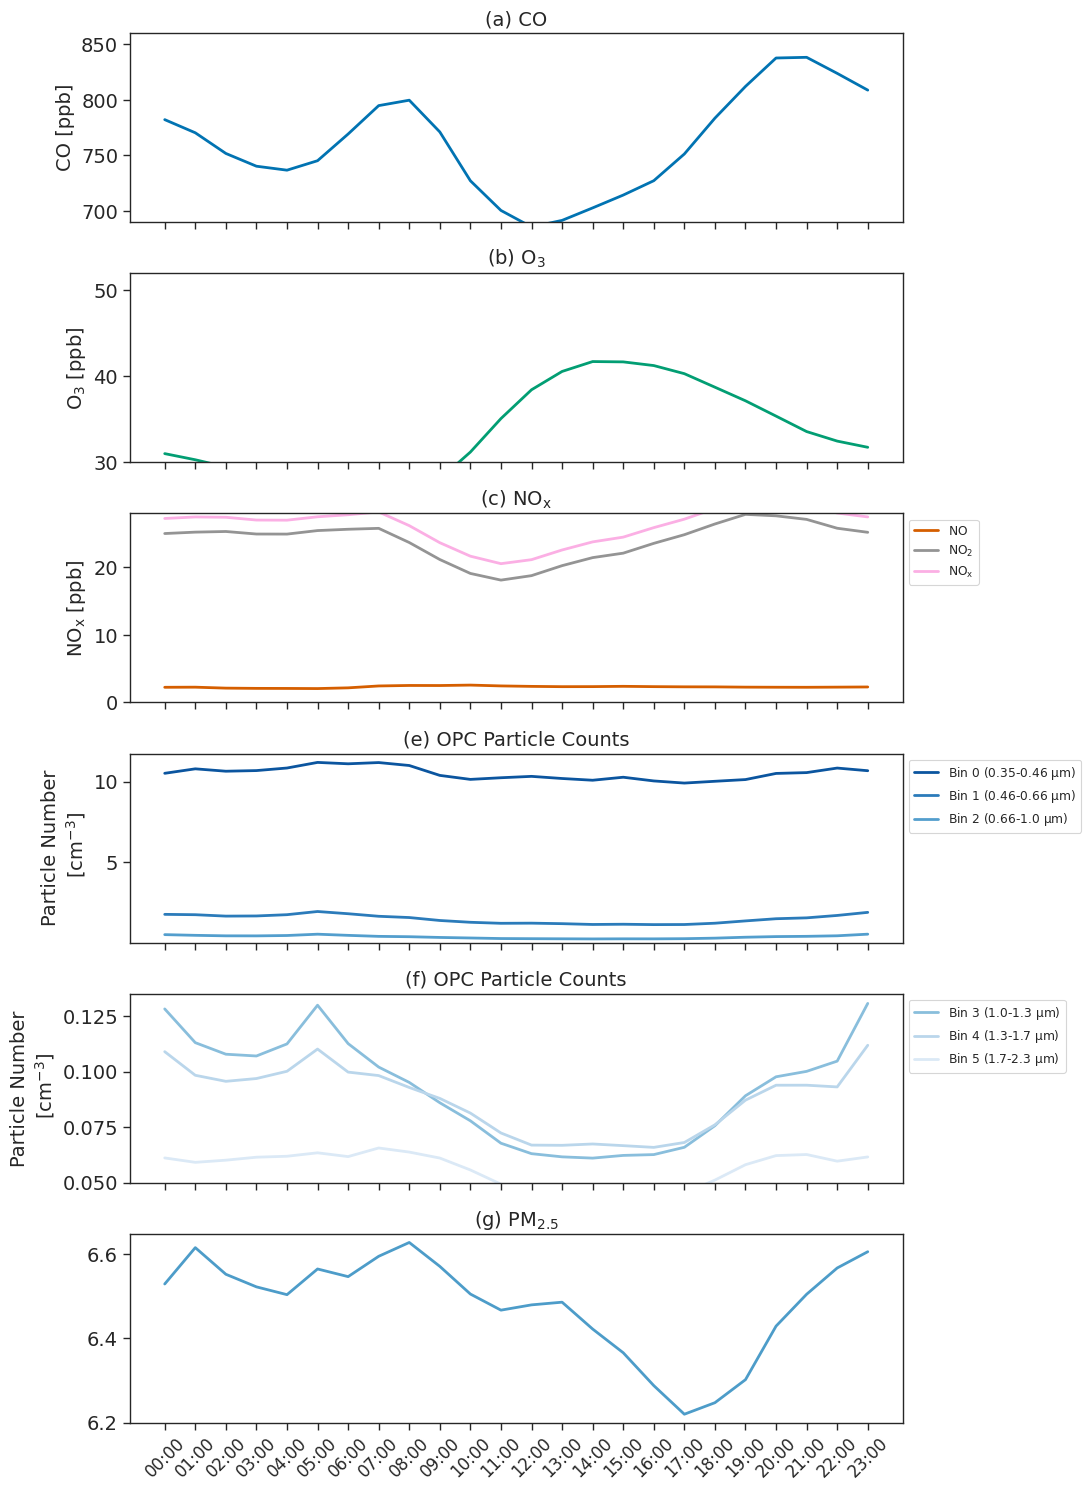

In [23]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/dirunal_MOD-00068_allfeatures.png')

## Diurnal by Season

In [24]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [25]:
ts_hour = ts_hour.reset_index()

In [26]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-05-27 14:00:00,4.404895,0.426842,0.150421,0.035500,0.041667,0.029167,7.058889,725.920722,51.733167,2.268667,13.966611,28.757895,27.647368,6.287107,14,Spring
1,2025-05-27 15:00:00,4.069783,0.454250,0.154917,0.038300,0.037350,0.022467,6.151050,773.013583,52.292650,2.301850,23.047433,30.191667,26.738333,6.005530,15,Spring
2,2025-05-27 16:00:00,3.978233,0.452267,0.173800,0.048567,0.049583,0.030067,4.484667,872.122700,50.222717,2.455000,30.014967,35.103333,25.531667,5.566494,16,Spring
3,2025-05-27 17:00:00,3.785383,0.444283,0.184617,0.054967,0.055600,0.040000,3.715817,931.487917,48.272367,2.512733,31.235817,38.311667,23.711667,5.323377,17,Spring
4,2025-05-27 18:00:00,3.911833,0.535150,0.215033,0.064917,0.061800,0.038883,3.371817,904.891483,44.823300,2.349117,31.505433,39.431667,22.640000,5.194161,18,Spring


In [27]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      5.681849  0.985506  0.366442  0.100022  0.094377  0.057837   
       1      6.035295  0.893690  0.298820  0.078681  0.077199  0.053410   
       2      6.241855  0.883949  0.287651  0.077625  0.078182  0.056638   
       3      6.600916  0.954664  0.306523  0.082236  0.082914  0.058296   
       4      6.974304  1.077509  0.336938  0.086891  0.082472  0.055033   
...                ...       ...       ...       ...       ...       ...   
Winter 19    10.917074  1.954019  0.541067  0.118844  0.084307  0.040474   
       20    11.541173  2.300461  0.595498  0.121242  0.083602  0.039412   
       21    10.848923  1.960327  0.519293  0.112496  0.080490  0.040088   
       22    11.611380  2.188510  0.573606  0.124715  0.091113  0.045360   
       23    14.161717  4.066449  1.272619  0.283664  0.218021  0.079968   

                  pm25          co         o3        no        no2         rh  \
Season Hour                                                                     
Autumn 0      5.027888  745.543460  28.192109  2.292800  28.164095  61.282659   
       1      5.068101  740.241966  27.338970  2.377025  28.351833  63.374635   
       2      5.119106  733.960888  26.529397  2.114050  29.208177  65.114082   
       3      5.183395  725.566016  25.579473  2.063313  29.188616  66.368845   
       4      5.028952  727.616007  24.670669  2.071871  28.866937  67.473842   
...                ...         ...        ...       ...        ...        ...   
Winter 19     8.289023  769.419044  23.604446  2.247986  32.665336  55.266488   
       20     9.035335  779.507242  23.299329  2.370993  32.399170  55.867440   
       21     8.359256  769.194127  23.142777  2.325849  32.155195  56.178512   
       22     8.530098  763.331735  23.032185  2.303011  32.016680  57.567500   
       23    10.281808  772.802414  22.501760  2.368365  32.141124  59.431190   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.441536  5.852171  
       1     14.991283  5.891850  
       2     14.614157  5.929939  
       3     14.300190  5.963514  
       4     14.019655  5.929983  
...                ...       ...  
Winter 19     2.277917  6.021420  
       20     2.010655  6.244881  
       21     1.844464  6.042566  
       22     1.686012  6.118890  
       23     1.391071  6.670881  

[96 rows x 14 columns]

In [28]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,5.681849,0.985506,0.366442,0.100022,0.094377,0.057837,5.027888,745.543460,28.192109,2.292800,28.164095,61.282659,15.441536,5.852171
1,Autumn,1,6.035295,0.893690,0.298820,0.078681,0.077199,0.053410,5.068101,740.241966,27.338970,2.377025,28.351833,63.374635,14.991283,5.891850
2,Autumn,2,6.241855,0.883949,0.287651,0.077625,0.078182,0.056638,5.119106,733.960888,26.529397,2.114050,29.208177,65.114082,14.614157,5.929939
3,Autumn,3,6.600916,0.954664,0.306523,0.082236,0.082914,0.058296,5.183395,725.566016,25.579473,2.063313,29.188616,66.368845,14.300190,5.963514
4,Autumn,4,6.974304,1.077509,0.336938,0.086891,0.082472,0.055033,5.028952,727.616007,24.670669,2.071871,28.866937,67.473842,14.019655,5.929983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,10.917074,1.954019,0.541067,0.118844,0.084307,0.040474,8.289023,769.419044,23.604446,2.247986,32.665336,55.266488,2.277917,6.021420
92,Winter,20,11.541173,2.300461,0.595498,0.121242,0.083602,0.039412,9.035335,779.507242,23.299329,2.370993,32.399170,55.867440,2.010655,6.244881
93,Winter,21,10.848923,1.960327,0.519293,0.112496,0.080490,0.040088,8.359256,769.194127,23.142777,2.325849,32.155195,56.178512,1.844464,6.042566
94,Winter,22,11.611380,2.188510,0.573606,0.124715,0.091113,0.045360,8.530098,763.331735,23.032185,2.303011,32.016680,57.567500,1.686012,6.118890


In [29]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [30]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,5.681849,0.985506,0.366442,0.100022,0.094377,0.057837,5.027888,745.543460,28.192109,2.292800,28.164095,61.282659,15.441536,5.852171
01:00,Autumn,1,6.035295,0.893690,0.298820,0.078681,0.077199,0.053410,5.068101,740.241966,27.338970,2.377025,28.351833,63.374635,14.991283,5.891850
02:00,Autumn,2,6.241855,0.883949,0.287651,0.077625,0.078182,0.056638,5.119106,733.960888,26.529397,2.114050,29.208177,65.114082,14.614157,5.929939
03:00,Autumn,3,6.600916,0.954664,0.306523,0.082236,0.082914,0.058296,5.183395,725.566016,25.579473,2.063313,29.188616,66.368845,14.300190,5.963514
04:00,Autumn,4,6.974304,1.077509,0.336938,0.086891,0.082472,0.055033,5.028952,727.616007,24.670669,2.071871,28.866937,67.473842,14.019655,5.929983
05:00,Autumn,5,7.493934,1.237974,0.386578,0.097581,0.088830,0.055571,4.981859,732.321586,23.544450,2.047022,29.277852,68.835714,13.809056,5.938104
06:00,Autumn,6,7.677911,1.339984,0.419283,0.103245,0.090918,0.055395,5.100957,760.080822,22.185477,2.156985,29.896313,69.471467,13.460914,5.971446
07:00,Autumn,7,7.977915,1.228435,0.363225,0.091709,0.086177,0.056790,5.375294,792.895920,21.975008,2.562189,30.152140,68.714817,13.615275,6.042757
08:00,Autumn,8,7.451431,1.016311,0.305662,0.080750,0.082473,0.058043,5.720004,798.316439,22.872556,2.404490,27.761244,64.918535,14.651117,6.106162
09:00,Autumn,9,6.416664,0.844477,0.273263,0.074555,0.079106,0.056337,5.481886,758.044558,24.554204,2.542472,24.201247,57.441740,16.803205,5.963364


In [31]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1297212592.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-1297212592.py:41: SyntaxWarning: invalid escape sequence '\m'


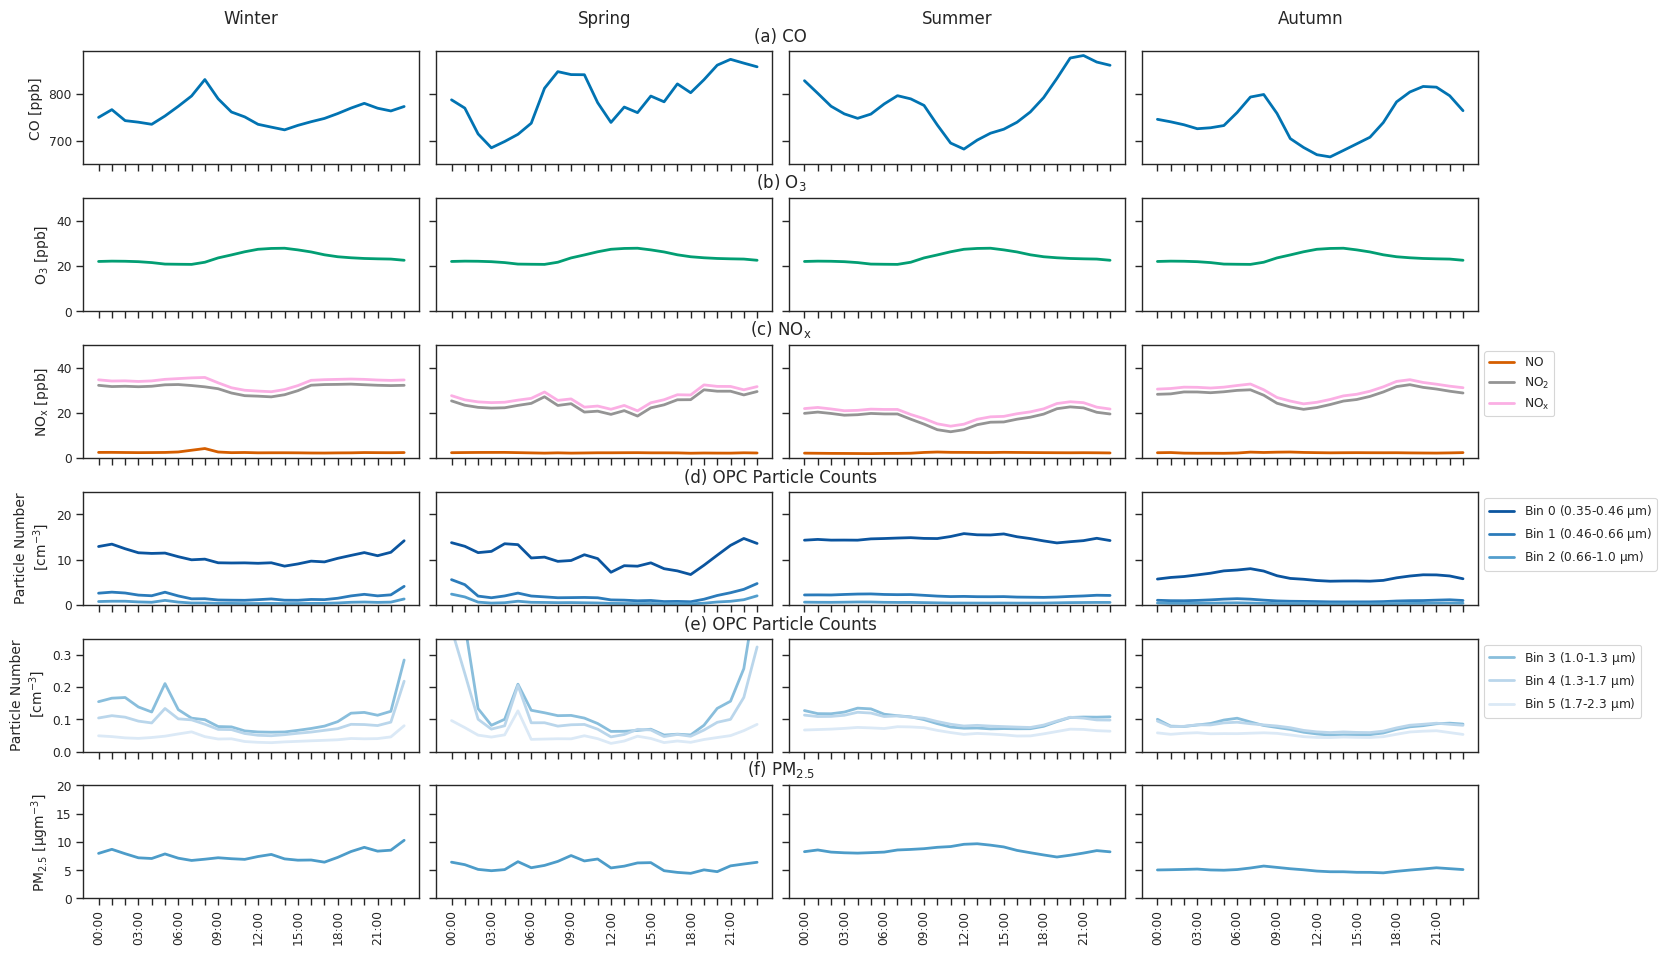

In [32]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/diurnal_by_season_MOD-000683.png')